# Task 4: Confidence-Based Strategy (UCB1)
**Group Number:** G = 225  
**Assignment:** DRL Semester 2 – Phase #1 (MAB)  
**Strategy:** Upper Confidence Bound (UCB1) — give under-explored medicines a statistical bonus that shrinks as evidence accumulates, naturally balancing exploration and exploitation without a fixed ε parameter.

In [1]:
# ─────────────────────────────────────────────────────────────────
# CELL 0 – Library Imports
# ─────────────────────────────────────────────────────────────────

import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [2]:
# ─────────────────────────────────────────────────────────────────
# CELL 1 – Restore Group Configuration & Reproducibility Seeds
#
# Loads the group configuration saved by Task 1 (group_config.json)
# and re-seeds the random engine to the same G=225 value so that
# simulate_treatment() produces reproducible Bernoulli draws.
# ─────────────────────────────────────────────────────────────────

# ── Locate the data directory relative to this notebook ──────────
NOTEBOOK_DIR = os.path.dirname(os.path.abspath("__file__"))
DATA_DIR     = os.path.join(NOTEBOOK_DIR, "data")
CONFIG_PATH  = os.path.join(DATA_DIR, "group_config.json")
PARQUET_PATH = os.path.join(DATA_DIR, "df_base.parquet")

# ── Load configuration ────────────────────────────────────────────
with open(CONFIG_PATH, "r") as f:
    cfg = json.load(f)

G      = cfg["G"]
K      = cfg["K"]
TRUE_P = cfg["TRUE_P"]

# ── Re-seed for reproducibility (same seed as all other tasks) ────
np.random.seed(G)

print("Configuration restored from group_config.json")
print(f"  G (Group Number)              : {G}")
print(f"  K (Number of Medicines/Arms)  : {K}")
print(f"  TRUE_P (Hidden Probabilities) : {TRUE_P}")

Configuration restored from group_config.json
  G (Group Number)              : 225
  K (Number of Medicines/Arms)  : 5
  TRUE_P (Hidden Probabilities) : [0.61, 0.68, 0.75, 0.4, 0.47]


In [3]:
# ─────────────────────────────────────────────────────────────────
# CELL 2 – Load df_base from Parquet
#
# Reads the clean base DataFrame persisted by Task 1.
# patient_id is restored as the index to match the original schema.
# ─────────────────────────────────────────────────────────────────

df_base = pd.read_parquet(PARQUET_PATH)
df_base.set_index("patient_id", inplace=True)

print(f"df_base loaded: {df_base.shape[0]} rows × {df_base.shape[1]} columns")
print(f"Columns        : {list(df_base.columns)}")
print()
print("First 5 rows (dynamic columns should be NaN):")
print(df_base.head())

df_base loaded: 1000 rows × 4 columns
Columns        : ['severity_score', 'assigned_medicine', 'clinical_outcome', 'utility_score']

First 5 rows (dynamic columns should be NaN):
            severity_score  assigned_medicine  clinical_outcome  utility_score
patient_id                                                                    
0                        1                NaN               NaN            NaN
1                        2                NaN               NaN            NaN
2                        3                NaN               NaN            NaN
3                        4                NaN               NaN            NaN
4                        5                NaN               NaN            NaN


In [4]:
# ─────────────────────────────────────────────────────────────────
# CELL 3 – Environmental Feedback Engine: simulate_treatment()
#
# Identical definition to Tasks 1, 2, and 3. Redefined here so
# this notebook is fully self-contained when run independently.
# ─────────────────────────────────────────────────────────────────

def simulate_treatment(medicine_idx: int, severity_score: int) -> tuple:
    """
    Simulate administering a medicine to a patient.

    Returns
    -------
    (clinical_outcome, utility_score) : tuple(int, float)
      clinical_outcome – 1 if recovered, 0 otherwise (Bernoulli trial)
      utility_score    – severity-penalised reward: outcome × (1 − sev/10)
    """
    success_prob     = TRUE_P[medicine_idx]
    clinical_outcome = int(np.random.binomial(1, success_prob))
    utility_score    = clinical_outcome * (1 - severity_score / 10)
    return (clinical_outcome, utility_score)

print("simulate_treatment() defined.")

simulate_treatment() defined.


In [5]:

# ─────────────────────────────────────────────────────────────────
# CELL 4 – Task 4: Confidence-Based Strategy – run_ucb1()
#
# Algorithm outline
# -----------------
# UCB1 resolves the exploration–exploitation dilemma without a
# fixed ε by augmenting each arm's empirical mean Q(i) with an
# upper-confidence bonus that is large for under-explored arms and
# shrinks as evidence accumulates:
#
#   UCB Score(i) = Q_t(i) + sqrt( 2 × ln(t) / N_t(i) )
#
# where:
#   Q_t(i)  = success_counts[i] / pull_counts[i]   (empirical success rate)
#   t       = 1-indexed global step (current patient number)
#   N_t(i)  = pull_counts[i]   (pulls for arm i so far)
#
# Phase 0 – Forced Initialisation (patients 0 to K-1):
#   Pull every arm exactly once (round-robin, arm i at patient i)
#   to guarantee pull_counts[i] > 0 before any UCB score is computed
#   (avoids division-by-zero inside the radical).
#
# Phase 1 – UCB1 Selection (patients K to 999):
#   Select arm i* = argmax UCB Score(i) and simulate treatment.
#   Arm with the highest score is prescribed to the next patient.
#
# Statistics updated using clinical_outcome (binary 0/1).
# Cumulative reward tracked using utility_score (severity-penalised).
# ─────────────────────────────────────────────────────────────────

def run_ucb1(n_patients: int = 1000, seed: int = None) -> tuple:
    """
    Run the UCB1 (Upper Confidence Bound 1) bandit strategy.

    UCB1 automatically balances exploration and exploitation without
    a manually tuned parameter: arms tried fewer times receive a larger
    optimism bonus, encouraging the algorithm to reduce uncertainty
    before committing to the empirically best arm.

    Parameters
    ----------
    n_patients : int – total patients to simulate (default 1000).
    seed       : int – RNG seed for reproducibility; defaults to G.

    Returns
    -------
    df             : pd.DataFrame  – one row per patient; columns:
                       patient_id (index), severity_score,
                       assigned_medicine, clinical_outcome,
                       utility_score, decision_type, cumulative_reward.
    history        : list[float]   – running cumulative reward at each
                       patient step (length == n_patients).
    success_counts : np.ndarray    – total successes (recoveries) per
                       medicine after the full simulation (shape K,).
    pull_counts    : np.ndarray    – total pulls per medicine (shape K,).
    """
    if seed is None:
        seed = G

    # ── Seed RNG for reproducibility ─────────────────────────────────
    np.random.seed(seed)

    # ── Working copy of base DataFrame; pre-allocate tracking columns ─
    df = df_base.copy(deep=True)
    df["decision_type"]    = ""       # forced_initial_test / ucb1_select
    df["cumulative_reward"] = np.nan  # running cumulative reward at each step

    # ── Fresh bandit statistics for this run ──────────────────────────
    success_counts = np.zeros(K, dtype=float)  # total recoveries per medicine
    pull_counts    = np.zeros(K, dtype=float)  # total pulls per medicine

    # ── Reward accumulator ────────────────────────────────────────────
    cumulative_reward = 0.0
    history           = []   # snapshot of cumulative_reward after each patient

    # ── Main simulation loop (t is the 1-indexed time step) ──────────
    for patient_id in range(n_patients):

        t        = patient_id + 1   # 1-indexed global step (used in UCB formula)
        severity = int(df.at[patient_id, "severity_score"])

        # ── Phase 0: Forced Initialisation (patients 0 … K-1) ────────
        # Pull every arm exactly once to guarantee pull_counts > 0 for
        # all arms before UCB scores can be computed safely.
        if patient_id < K:
            chosen_medicine = patient_id       # t=1→arm0, t=2→arm1, …, t=K→arm(K-1)
            decision_type   = "forced_initial_test"

        # ── Phase 1: UCB1 Selection (patients K … n_patients-1) ──────
        else:
            # Empirical success rate for each arm
            Q = success_counts / pull_counts   # pull_counts > 0 guaranteed

            # Exploration bonus: large when N_t(i) is small; shrinks over time
            bonus = np.sqrt(2 * np.log(t) / pull_counts)

            ucb_scores      = Q + bonus
            chosen_medicine = int(np.argmax(ucb_scores))   # ties broken by first max
            decision_type   = "ucb1_select"

        # ── Simulate treatment outcome ─────────────────────────────────
        clinical_outcome, utility_score = simulate_treatment(
            chosen_medicine, severity
        )

        # ── Update bandit statistics (binary clinical_outcome only) ────
        success_counts[chosen_medicine] += clinical_outcome
        pull_counts[chosen_medicine]    += 1

        # ── Update cumulative reward (utility_score, not clinical) ─────
        cumulative_reward += utility_score
        history.append(cumulative_reward)

        # ── Write results into the DataFrame row ──────────────────────
        df.at[patient_id, "assigned_medicine"]  = chosen_medicine
        df.at[patient_id, "clinical_outcome"]   = clinical_outcome
        df.at[patient_id, "utility_score"]      = utility_score
        df.at[patient_id, "decision_type"]      = decision_type
        df.at[patient_id, "cumulative_reward"]  = cumulative_reward

    return df, history, success_counts, pull_counts


print("run_ucb1() defined.")
print(f"  Signature  : run_ucb1(n_patients=1000, seed=G)")
print(f"  Returns    : (df, history, success_counts, pull_counts)")
print(f"  K = {K}  →  forced initialisation covers patients 0–{K - 1}")
print(f"  Phase 1 UCB1 selection starts from patient {K} onward")


run_ucb1() defined.
  Signature  : run_ucb1(n_patients=1000, seed=G)
  Returns    : (df, history, success_counts, pull_counts)
  K = 5  →  forced initialisation covers patients 0–4
  Phase 1 UCB1 selection starts from patient 5 onward


In [6]:

# ─────────────────────────────────────────────────────────────────
# CELL 4b – Execute UCB1 Simulation
#
# Calls run_ucb1() with the group seed (G = 225) and unpacks results
# into clearly named variables that are reused by the verification,
# persistence, and plotting cells that follow.
# ─────────────────────────────────────────────────────────────────

# ── Run the UCB1 simulation (1000 patients, seed = G) ─────────────
df_ucb, ucb_utility_history, success_counts, pull_counts = run_ucb1(
    n_patients=1000, seed=G
)

# ── Named alias for cross-task comparison (Task 5) ────────────────
ucb1_log = df_ucb

# ── Derive convenience scalars reused in downstream cells ─────────
# Final cumulative reward after processing all 1000 patients
cumulative_reward = ucb_utility_history[-1]

print("UCB1 simulation complete.")
print(f"  Total iterations     : {len(ucb_utility_history)}")
print(f"  Final cum. reward    : {cumulative_reward:.4f}")
print(f"  Total pulls (check)  : {int(pull_counts.sum())}")
print(f"  Named log variable   : ucb1_log  "
      f"({ucb1_log.shape[0]} rows × {ucb1_log.shape[1]} cols)")


UCB1 simulation complete.
  Total iterations     : 1000
  Final cum. reward    : 466.7000
  Total pulls (check)  : 1000
  Named log variable   : ucb1_log  (1000 rows × 6 cols)


In [7]:

# ─────────────────────────────────────────────────────────────────
# CELL 5 – Validation Checks + Detailed UCB1 Output
#
# 1. Validate all simulation invariants (same checks as Task 3).
# 2. Print final cumulative reward.
# 3. Pull distribution, empirical success rates, and UCB final scores.
# 4. Decision-type breakdown (forced_initial_test / ucb1_select).
# 5. Transition slice (first 10 rows) for initialisation verification.
# ─────────────────────────────────────────────────────────────────

TRUE_OPTIMAL = int(np.argmax(TRUE_P))

# ── Compute final empirical rates and UCB scores ──────────────────
empirical_rates    = success_counts / pull_counts
best_arm_empirical = int(np.argmax(empirical_rates))

# Final UCB scores at t=1000 (for reporting purposes only)
t_final    = 1000
final_bonus = np.sqrt(2 * np.log(t_final) / pull_counts)
final_ucb   = empirical_rates + final_bonus

# ── Validation ────────────────────────────────────────────────────
def validate_ucb1_run(df: pd.DataFrame, pc: np.ndarray) -> None:
    """
    Assert all simulation invariants for the UCB1 run and print
    PASS/FAIL for each check.

    Parameters
    ----------
    df : pd.DataFrame – simulation log (patient_id as index)
    pc : np.ndarray   – per-arm pull counts (shape K)
    """
    errors = []

    if len(df) != 1000:
        errors.append(f"  ✗ Row count: {len(df)} (expected 1000)")

    if df["assigned_medicine"].isna().any():
        errors.append("  ✗ NaN in assigned_medicine")
    elif not df["assigned_medicine"].between(0, K - 1).all():
        errors.append("  ✗ assigned_medicine out of range [0, K-1]")

    if df["clinical_outcome"].isna().any():
        errors.append("  ✗ NaN in clinical_outcome")
    elif not df["clinical_outcome"].isin([0, 1]).all():
        errors.append("  ✗ clinical_outcome outside {0, 1}")

    expected_utility = df["clinical_outcome"] * (1 - df["severity_score"] / 10)
    if not np.allclose(df["utility_score"].values,
                       expected_utility.values, atol=1e-9):
        errors.append("  ✗ utility_score formula mismatch")

    if (df["cumulative_reward"].diff().dropna() < -1e-9).any():
        errors.append("  ✗ cumulative_reward is not non-decreasing")

    if int(pc.sum()) != 1000:
        errors.append(f"  ✗ Sum of pull_counts = {int(pc.sum())} (expected 1000)")

    for col in ("utility_score", "cumulative_reward"):
        if df[col].isna().any():
            errors.append(f"  ✗ NaN in {col}")

    status = "PASS ✓" if not errors else "FAIL ✗"
    print(f"  Validation [UCB1] : {status}")
    for e in errors:
        print(e)


print("Running validation …")
validate_ucb1_run(df_ucb, pull_counts)
print()

# ── Main results report ───────────────────────────────────────────
print("=" * 65)
print("TASK 4 – UCB1 CONFIDENCE-BASED STRATEGY RESULTS  (G = 225)")
print("=" * 65)
print(f"  True optimal medicine     : {TRUE_OPTIMAL}  "
      f"(P = {TRUE_P[TRUE_OPTIMAL]:.2f})")
print(f"  Forced init phase         : first {K} patients (one pull per arm)")
print()
print(f"  Final cumulative reward (1000 patients) : {cumulative_reward:.4f}")
print()

# Pull distribution table
print("  Pull Distribution & Empirical Rates (UCB1 final state):")
header = f"  {'Medicine':<12} {'Pulls':>8} {'Empirical Rate':>16} {'True P':>8} {'Final UCB':>12}"
print(header)
print("  " + "-" * 60)
for idx in range(K):
    tag = ""
    if idx == TRUE_OPTIMAL:
        tag = "  ← OPTIMAL"
    elif idx == best_arm_empirical:
        tag = "  ← SELECTED (non-optimal)"
    print(f"  Medicine {idx}   {int(pull_counts[idx]):>8}   {empirical_rates[idx]:>14.4f}"
          f"   {TRUE_P[idx]:>6.2f}   {final_ucb[idx]:>10.4f}{tag}")

print()
match_str = "← MATCHES OPTIMAL ✓" if best_arm_empirical == TRUE_OPTIMAL \
            else "← SUBOPTIMAL ✗"
print(f"  Best arm by empirical rate : Medicine {best_arm_empirical}  {match_str}")

# ── Decision-type breakdown ───────────────────────────────────────
dtypes = df_ucb["decision_type"].value_counts().to_dict()
print()
print(f"  Decision-type breakdown    : "
      f"forced_initial_test={dtypes.get('forced_initial_test', 0)}, "
      f"ucb1_select={dtypes.get('ucb1_select', 0)}")

# ── Transition slice ──────────────────────────────────────────────
print()
print("-" * 65)
print(f"Initialisation phase – df_ucb.iloc[0:{K + 5}]")
print(f"(Rows 0–{K-1}: forced_initial_test | Rows {K}+: ucb1_select)")
print("-" * 65)
print(
    df_ucb.reset_index()
    .iloc[0:K + 5]
    [["patient_id", "severity_score", "assigned_medicine",
      "clinical_outcome", "utility_score", "decision_type", "cumulative_reward"]]
    .to_string(index=False)
)
print("=" * 65)


Running validation …
  Validation [UCB1] : PASS ✓

TASK 4 – UCB1 CONFIDENCE-BASED STRATEGY RESULTS  (G = 225)
  True optimal medicine     : 2  (P = 0.75)
  Forced init phase         : first 5 patients (one pull per arm)

  Final cumulative reward (1000 patients) : 466.7000

  Pull Distribution & Empirical Rates (UCB1 final state):
  Medicine        Pulls   Empirical Rate   True P    Final UCB
  ------------------------------------------------------------
  Medicine 0        164           0.6220     0.61       0.9122
  Medicine 1        258           0.6822     0.68       0.9136
  Medicine 2        468           0.7415     0.75       0.9133  ← OPTIMAL
  Medicine 3         60           0.4333     0.40       0.9132
  Medicine 4         50           0.3800     0.47       0.9057

  Best arm by empirical rate : Medicine 2  ← MATCHES OPTIMAL ✓

  Decision-type breakdown    : forced_initial_test=5, ucb1_select=995

-----------------------------------------------------------------
Initialisatio

In [8]:

# ─────────────────────────────────────────────────────────────────
# CELL 6 – Persist Outputs for Task 5 (Comparative Plots)
#
# Saves df_ucb (as Parquet) and ucb_utility_history (as .npy) so
# the Task 5 notebook can load them alongside outputs from Tasks 2
# and 3 and generate multi-algorithm comparative reward curves
# without re-running any simulations.
# ─────────────────────────────────────────────────────────────────

UCB_PARQUET_PATH = os.path.join(DATA_DIR, "df_ucb.parquet")
UCB_HISTORY_PATH = os.path.join(DATA_DIR, "ucb_utility_history.npy")

# Save df_ucb (reset index so patient_id becomes a regular column)
df_ucb.reset_index().to_parquet(UCB_PARQUET_PATH, index=False)

# Save cumulative-reward history as a NumPy array
np.save(UCB_HISTORY_PATH, np.array(ucb_utility_history))

print(f"df_ucb saved              → {UCB_PARQUET_PATH}")
print(f"ucb_utility_history saved → {UCB_HISTORY_PATH}")
print(f"df_ucb shape              : {df_ucb.shape}")
print(f"History length            : {len(ucb_utility_history)}")


df_ucb saved              → /home/kanchan.chauhan/kanchan_bits/SEM2_DRL_ASSIGNMENT_PART1/Part_1/data/df_ucb.parquet
ucb_utility_history saved → /home/kanchan.chauhan/kanchan_bits/SEM2_DRL_ASSIGNMENT_PART1/Part_1/data/ucb_utility_history.npy
df_ucb shape              : (1000, 6)
History length            : 1000


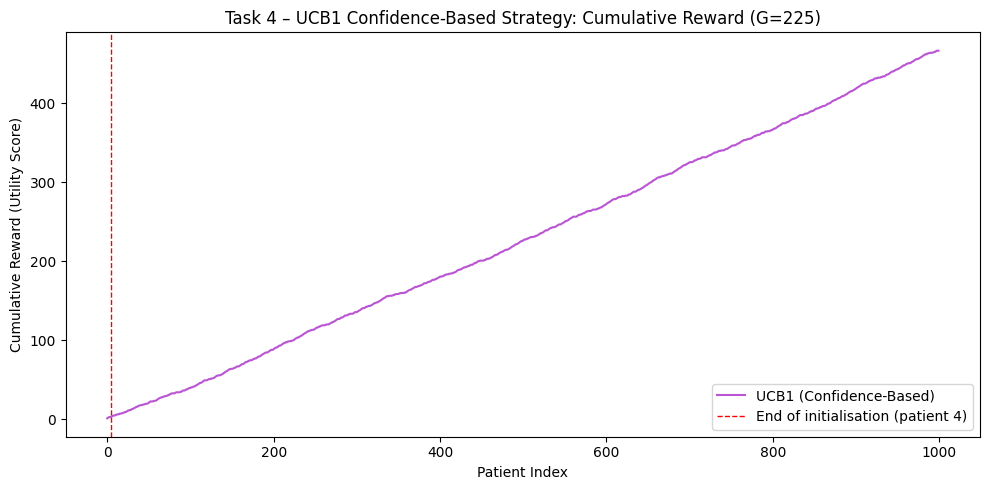

In [9]:
# ─────────────────────────────────────────────────────────────────
# CELL 7 – Quick Reward Curve (Task 4 Preview)
#
# Plots the UCB1 cumulative reward trajectory with annotations
# marking the end of the mandatory initialisation phase.
# The curve should climb steeply once UCB1 identifies Medicine 2
# and allocates most pulls to the optimal arm.
# ─────────────────────────────────────────────────────────────────

plt.figure(figsize=(10, 5))
plt.plot(ucb_utility_history, color="mediumorchid", linewidth=1.5,
         label="UCB1 (Confidence-Based)")
plt.axvline(x=K - 1, color="red", linestyle="--", linewidth=1,
            label=f"End of initialisation (patient {K - 1})")
plt.xlabel("Patient Index")
plt.ylabel("Cumulative Reward (Utility Score)")
plt.title("Task 4 – UCB1 Confidence-Based Strategy: Cumulative Reward (G=225)")
plt.legend()
plt.tight_layout()
plt.show()

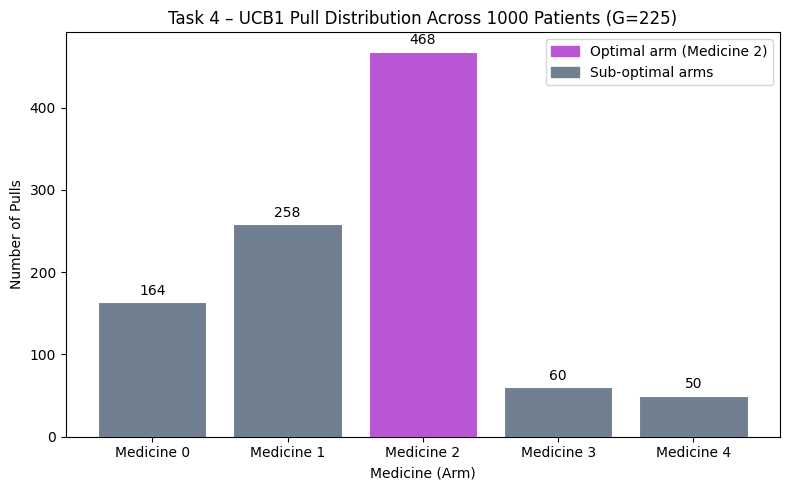

In [10]:
# ─────────────────────────────────────────────────────────────────
# CELL 8 – Pull Distribution Bar Chart
#
# Visualises how many times each medicine was selected across the
# 1000 patients.  An effective UCB1 run should show Medicine 2
# (the optimal arm, P=0.75) dominating the pull count while other
# medicines still receive exploratory pulls.
# ─────────────────────────────────────────────────────────────────

colors = ["mediumorchid" if idx == TRUE_OPTIMAL else "slategray" for idx in range(K)]

plt.figure(figsize=(8, 5))
bars = plt.bar([f"Medicine {i}" for i in range(K)],
               pull_counts.astype(int),
               color=colors, edgecolor="white", linewidth=0.8)

# Annotate each bar with the exact pull count
for bar, count in zip(bars, pull_counts.astype(int)):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 5,
             str(count),
             ha="center", va="bottom", fontsize=10)

plt.xlabel("Medicine (Arm)")
plt.ylabel("Number of Pulls")
plt.title("Task 4 – UCB1 Pull Distribution Across 1000 Patients (G=225)")
plt.legend(
    handles=[
        plt.Rectangle((0, 0), 1, 1, color="mediumorchid", label="Optimal arm (Medicine 2)"),
        plt.Rectangle((0, 0), 1, 1, color="slategray",    label="Sub-optimal arms"),
    ]
)
plt.tight_layout()
plt.show()

In [11]:

# ─────────────────────────────────────────────────────────────────
# CELL 9 – Final Compact Summary Table (All Strategies)
#
# Loads persisted outputs from Tasks 2, 3, and 4, then builds a
# single summary DataFrame comparing all MAB strategies across:
#   • final_cumulative_reward  – total utility after 1000 patients
#   • most_selected_medicine   – arm pulled the most times
#   • estimated_best_medicine  – arm with highest empirical Q value
#   • estimated_success_rates  – Q values at end of simulation
#
# This table is the authoritative cross-task performance summary and
# is also used as input for the Task 5 comparative analysis.
# ─────────────────────────────────────────────────────────────────

import os
import json
import numpy as np
import pandas as pd

# ── Locate data directory ─────────────────────────────────────────
NOTEBOOK_DIR = os.path.dirname(os.path.abspath("__file__"))
DATA_DIR_S   = os.path.join(NOTEBOOK_DIR, "data")

# ── Load saved histories ──────────────────────────────────────────
# Each .npy file is a 1-D array of cumulative reward after each patient.
greedy_hist  = np.load(os.path.join(DATA_DIR_S, "greedy_utility_history.npy"))
eps001_hist  = np.load(os.path.join(DATA_DIR_S, "epsilon_greedy_history_001.npy"))
eps010_hist  = np.load(os.path.join(DATA_DIR_S, "epsilon_greedy_history_010.npy"))
eps050_hist  = np.load(os.path.join(DATA_DIR_S, "epsilon_greedy_history_050.npy"))
ucb_hist     = np.load(os.path.join(DATA_DIR_S, "ucb_utility_history.npy"))

# ── Load saved DataFrames for pull-count & empirical-rate info ────
df_g   = pd.read_parquet(os.path.join(DATA_DIR_S, "df_greedy.parquet"))
df_e01 = pd.read_parquet(os.path.join(DATA_DIR_S, "df_epsilon_greedy_001.parquet"))
df_e10 = pd.read_parquet(os.path.join(DATA_DIR_S, "df_epsilon_greedy_010.parquet"))
df_e50 = pd.read_parquet(os.path.join(DATA_DIR_S, "df_epsilon_greedy_050.parquet"))
df_u   = pd.read_parquet(os.path.join(DATA_DIR_S, "df_ucb.parquet"))


def summarise_strategy(name: str, history: np.ndarray,
                       df: pd.DataFrame) -> dict:
    """
    Compute summary statistics for one bandit strategy run.

    Parameters
    ----------
    name    : str          – display label for this strategy.
    history : np.ndarray   – cumulative reward array (length 1000).
    df      : pd.DataFrame – simulation log (patient_id as regular column
                             or as index; assigned_medicine column required).

    Returns
    -------
    dict with keys:
      strategy, final_cumulative_reward, most_selected_medicine,
      estimated_best_medicine, estimated_success_rates
    """
    # Ensure patient_id is a column (not the index) for uniform access
    if "patient_id" not in df.columns:
        df = df.reset_index()

    # Pull counts per medicine derived from the assignment column
    pull_counts    = np.array([
        (df["assigned_medicine"] == i).sum() for i in range(K)
    ], dtype=float)

    # Success counts from clinical_outcome column
    success_counts = np.array([
        df.loc[df["assigned_medicine"] == i, "clinical_outcome"].sum()
        for i in range(K)
    ], dtype=float)

    # Empirical success rate (Q value) per medicine
    Q = np.where(pull_counts > 0, success_counts / pull_counts, 0.0)

    return {
        "strategy"                 : name,
        "final_cumulative_reward"  : round(history[-1], 4),
        "most_selected_medicine"   : int(np.argmax(pull_counts)),
        "estimated_best_medicine"  : int(np.argmax(Q)),
        "estimated_success_rates"  : [round(q, 4) for q in Q.tolist()],
    }


# ── Build summary rows ────────────────────────────────────────────
rows = [
    summarise_strategy("Greedy (Task 2 – Pure Exploitation)",   greedy_hist, df_g),
    summarise_strategy("ε-Greedy ε=0.01 (Task 3 – Low)",        eps001_hist, df_e01),
    summarise_strategy("ε-Greedy ε=0.10 (Task 3 – Moderate)",   eps010_hist, df_e10),
    summarise_strategy("ε-Greedy ε=0.50 (Task 3 – High)",       eps050_hist, df_e50),
    summarise_strategy("UCB1   (Task 4 – Confidence-Based)",     ucb_hist,    df_u),
]

summary_df = pd.DataFrame(rows)

# ── Display the summary table ─────────────────────────────────────
print("=" * 75)
print("FINAL COMPACT SUMMARY – All MAB Strategies  (G = 225, 1000 patients)")
print("=" * 75)
print()
print(summary_df.to_string(index=False))
print()

# ── Highlight best overall strategy ──────────────────────────────
best_idx = summary_df["final_cumulative_reward"].idxmax()
print("-" * 75)
print(f"Highest cumulative reward : "
      f"{summary_df.loc[best_idx, 'strategy']}")
print(f"  Reward = {summary_df.loc[best_idx, 'final_cumulative_reward']:.4f}")
print()

# ── Strategies that identified the true optimal medicine ──────────
TRUE_OPTIMAL_SUMMARY = int(np.argmax([0.61, 0.68, 0.75, 0.40, 0.47]))
converged = summary_df[
    summary_df["estimated_best_medicine"] == TRUE_OPTIMAL_SUMMARY
]["strategy"].tolist()
print(f"True optimal medicine : {TRUE_OPTIMAL_SUMMARY}  (P = 0.75)")
print(f"Strategies that converged to optimal : {converged}")
print("=" * 75)


FINAL COMPACT SUMMARY – All MAB Strategies  (G = 225, 1000 patients)

                           strategy  final_cumulative_reward  most_selected_medicine  estimated_best_medicine                  estimated_success_rates
Greedy (Task 2 – Pure Exploitation)                    513.1                       2                        2             [0.6, 0.4, 0.7417, 0.6, 0.6]
     ε-Greedy ε=0.01 (Task 3 – Low)                    515.2                       2                        2       [0.5333, 0.5714, 0.7456, 0.5, 0.2]
ε-Greedy ε=0.10 (Task 3 – Moderate)                    493.2                       2                        2   [0.5625, 0.6923, 0.7248, 0.25, 0.5517]
    ε-Greedy ε=0.50 (Task 3 – High)                    474.0                       2                        2 [0.6321, 0.7019, 0.7459, 0.4487, 0.4592]
 UCB1   (Task 4 – Confidence-Based)                    466.7                       2                        2    [0.622, 0.6822, 0.7415, 0.4333, 0.38]

-----------------------